### **Exercícios de Regressão – Linear, Múltipla e Polinomial**


### 1. Regressão Linear Simples – Exercícios

**Exercício 1:**

Neste exercício, vamos gerar dados seguindo o modelo:

$$y = 3x + 2 + w,$$


onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e variância unitária.

O objetivo é ajustar um modelo de regressão linear e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.

---

**Exercício 2:**

Crie um conjunto de dados com $N = 100$ amostras seguindo o modelo:

$$y = \beta_0 + \beta_1 x + w,$$


onde:

- $x$ é um vetor coluna com $N$ elementos gerados a partir de uma distribuição **uniforme** no intervalo $[0, 10]$, representando os **anos de uso**;
- $\beta_0 = 50\,000$ é o preço inicial sem uso;
- $\beta_1 = -3\,000$ é a taxa de desvalorização por ano (relação linear decrescente);
- $w$ é um vetor coluna com $N$ elementos amostrados de uma **distribuição normal Gaussiana** com média zero e desvio padrão $\sigma = 2000$, representando ruído no preço.

Treine um modelo de regressão linear para estimar $\beta_0$ e $\beta_1$ e compare esses valores com os coeficientes reais. Plote a função original, os dados ruidosos e a reta estimada.

-----------------------------------------------------------
### 2. Regressão Linear Múltipla – Exercícios

**Exercício 3:**

Considere o modelo linear:

$$y = 5 + 3x_1 - 2x_2 + w,$$

onde:

- $x_1$ e $x_2$ são vetores coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é ajustar um modelo de regressão linear múltipla e comparar os coeficientes reais com os estimados. Plote a função original, os dados ruidosos e a reta estimada.

**Exercício 4:**

Neste exercício, vamos investigar o impacto da normalização quando trabalhamos com variáveis que possuem **escalas muito diferentes**.

Considere:

- $x_1$: variável na escala de **0 a 10**.  
- $x_2$: variável na escala de **0 a 10.000**.

O modelo real utilizado para gerar os dados será:

$$y = 4x_1 + 0.002x_2 + w,$$

onde o ruído $w$ segue uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 5$.

O objetivo é:

1. Treinar um **modelo sem normalização**.  
2. Treinar um **modelo com normalização via StandardScaler**.  
3. Comparar coeficientes e plotar a função original, os dados ruidosos e a reta estimada.  
4. Explicar por que a normalização impacta os coeficientes.

-----------------------------------------------------------
 ### 3. Regressão Polinomial – Exercícios

**Exercício 5:**
Considere o seguinte modelo gerador de dados:

$$
y = 2x^2 - x + 1 + w,
$$

onde:

- $x$ é um vetor coluna com $N = 1000$ amostras geradas de forma independente a partir de uma distribuição uniforme no intervalo $[-1, 1]$;
- $w$ é um vetor coluna com $N$ amostras extraídas de uma distribuição normal Gaussiana com média zero e desvio padrão $\sigma = 0.5$.

O objetivo é analisar o comportamento da regressão polinomial ao tentar aproximar um modelo não linear verdadeiro utilizando diferentes graus de complexidade.
Treine modelos de regressão polinomial considerando as seguintes hipóteses:

- Grau 1 (modelo linear):

$$
y \approx \beta_0 + \beta_1 x
$$

- Grau 2 (modelo correto em relação ao processo gerador):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2
$$

- Grau 3 (modelo superparametrizado):

$$
y \approx \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3
$$

**Objetivo:**

Comparar o desempenho dos três modelos em termos de:

- capacidade de aproximação da função verdadeira;
- plotar a função original, os dados ruidosos e a reta estimada.
- impacto da complexidade do modelo (underfitting vs. overfitting);
- influência do termo de ruído $w$ na estimativa dos coeficientes.

Coeficiente Real: 3.000 ---- Estimado: 2.923
Intercepto Real: 2.000 ---- Estimado: 2.097


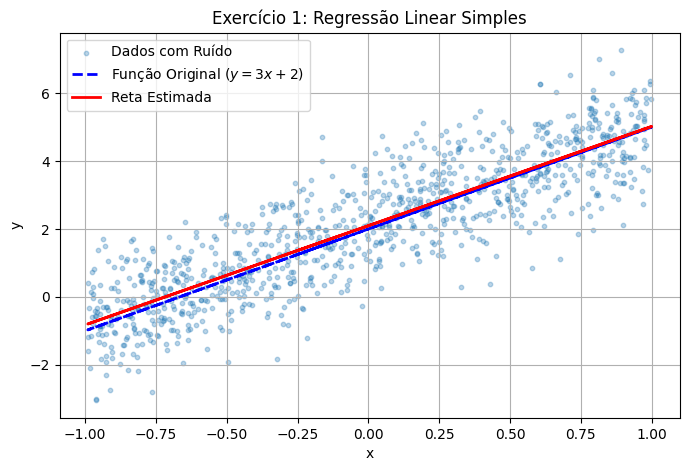

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Gerando os dados
np.random.seed(42)
N = 1000
x = np.random.uniform(-1, 1, N).reshape(N, 1)
w = np.random.randn(N, 1) # Variância 1, logo desvio padrão também é 1
y = 3*x + 2
y_noisy = y + w

# 2. Treinando o modelo
model = LinearRegression()
model.fit(x, y_noisy)

# 3. Predição e Coeficientes
y_pred = model.predict(x)
print(f"Coeficiente Real: 3.000 ---- Estimado: {model.coef_[0][0]:.3f}")
print(f"Intercepto Real: 2.000 ---- Estimado: {model.intercept_[0]:.3f}")

# 4. Gráfico
plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, alpha=0.3, label="Dados com Ruído", s=10)
plt.plot(x, y, 'b--', linewidth=2, label="Função Original ($y = 3x + 2$)")
plt.plot(x, y_pred, 'r-', linewidth=2, label="Reta Estimada")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Exercício 1: Regressão Linear Simples")
plt.legend()
plt.grid(True)
plt.show()

Taxa de desvalorização Real: -3000 ---- Estimada: -3091.955
Preço inicial Real: 50000 ----- Estimado: 50430.192


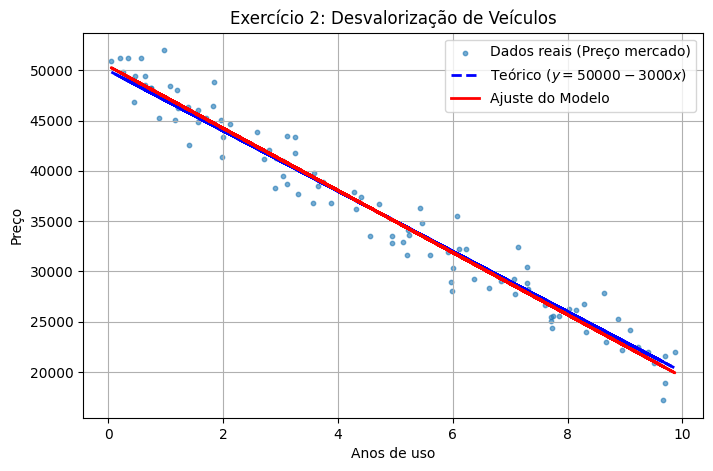

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


np.random.seed(42)
N = 100
x = np.random.uniform(0, 10, N).reshape(N, 1) 
w = 2000 * np.random.randn(N, 1) 
y = 50000 - 3000 * x
y_noisy = y + w


model = LinearRegression()
model.fit(x, y_noisy)


y_pred = model.predict(x)
print(f"Taxa de desvalorização Real: -3000 ---- Estimada: {model.coef_[0][0]:.3f}")
print(f"Preço inicial Real: 50000 ----- Estimado: {model.intercept_[0]:.3f}")



plt.figure(figsize=(8, 5))
plt.scatter(x, y_noisy, alpha=0.6, label="Dados reais (Preço mercado)", s=10)
plt.plot(x, y, 'b--', linewidth=2, label="Teórico ($y = 50000 - 3000x$)")
plt.plot(x, y_pred, 'r-', linewidth=2, label="Ajuste do Modelo")
plt.xlabel("Anos de uso")
plt.ylabel("Preço")
plt.title("Exercício 2: Desvalorização de Veículos")
plt.legend()
plt.grid(True)
plt.show()

Intercepto Real: 5  Estimado: 5.006
Coeficientes Reais: 3, -2  Estimados: 2.992, -2.001


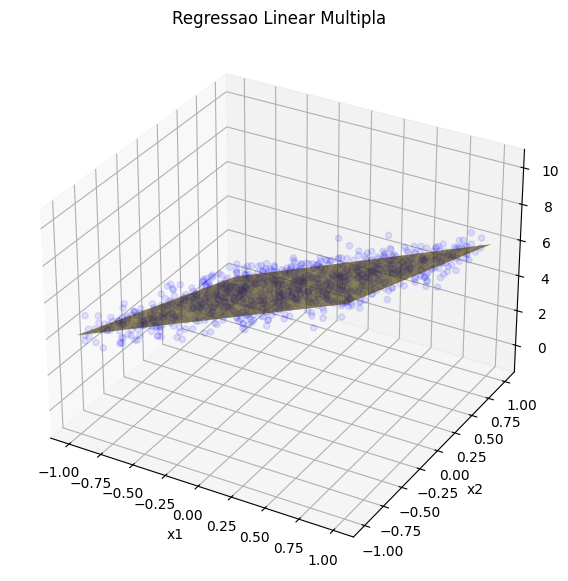

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
N = 1000
x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)
X = np.column_stack((x1, x2))

# sigma = 0.5
w = 0.5 * np.random.randn(N) 
y = 5 + 3*x1 - 2*x2
y_noisy = y + w

model = LinearRegression()
model.fit(X, y_noisy)

print(f"Intercepto Real: 5  Estimado: {model.intercept_:.3f}")
print(f"Coeficientes Reais: 3, -2  Estimados: {model.coef_[0]:.3f}, {model.coef_[1]:.3f}")

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, y_noisy, alpha=0.1, color='blue', label='Dados ruidosos')

x1_grid, x2_grid = np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))
y_grid_orig = 5 + 3*x1_grid - 2*x2_grid
y_grid_pred = model.intercept_ + model.coef_[0]*x1_grid + model.coef_[1]*x2_grid

ax.plot_surface(x1_grid, x2_grid, y_grid_orig, alpha=0.4, color='green')
ax.plot_surface(x1_grid, x2_grid, y_grid_pred, alpha=0.4, color='red')

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Regressao Linear Multipla")
ax.set_zlabel("y")

plt.show()

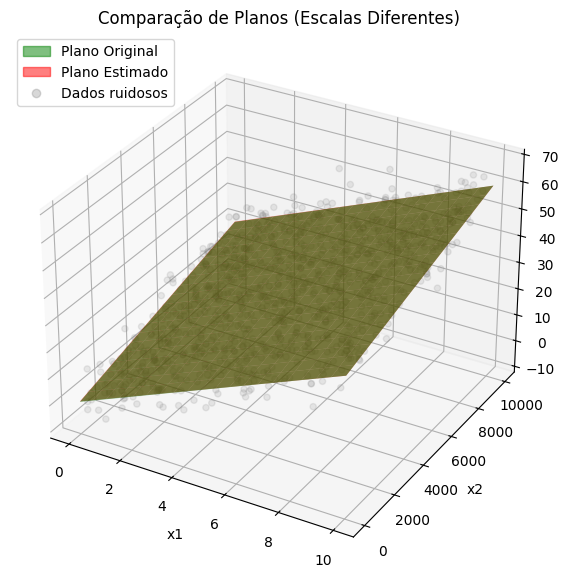

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

np.random.seed(42)
N = 1000
x1 = np.random.uniform(0, 10, N)
x2 = np.random.uniform(0, 10000, N)
X = np.column_stack((x1, x2))

w = 5 * np.random.randn(N) 
y = 4*x1 + 0.002*x2
y_noisy = y + w

model = LinearRegression()
model.fit(X, y_noisy)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y_noisy)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x1, x2, y_noisy, alpha=0.15, color='gray', label='Dados ruidosos')

x1_grid, x2_grid = np.meshgrid(np.linspace(0, 10, 20), np.linspace(0, 10000, 20))

y_grid_orig = 4*x1_grid + 0.002*x2_grid
y_grid_pred = model.intercept_ + model.coef_[0]*x1_grid + model.coef_[1]*x2_grid


ax.plot_surface(x1_grid, x2_grid, y_grid_pred, alpha=0.5, color='red')
ax.plot_surface(x1_grid, x2_grid, y_grid_orig, alpha=0.5, color='green')

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("y")
ax.set_title("Comparação de Planos (Escalas Diferentes)")


red_patch = mpatches.Patch(color='red', alpha=0.5, label='Plano Estimado')

green_patch = mpatches.Patch(color='green', alpha=0.5, label='Plano Original')
gray_dot = Line2D([0], [0], linestyle="none", marker="o", color="gray", alpha=0.3, label='Dados ruidosos')


ax.legend(handles=[green_patch, red_patch, gray_dot], loc='upper left')

plt.show()

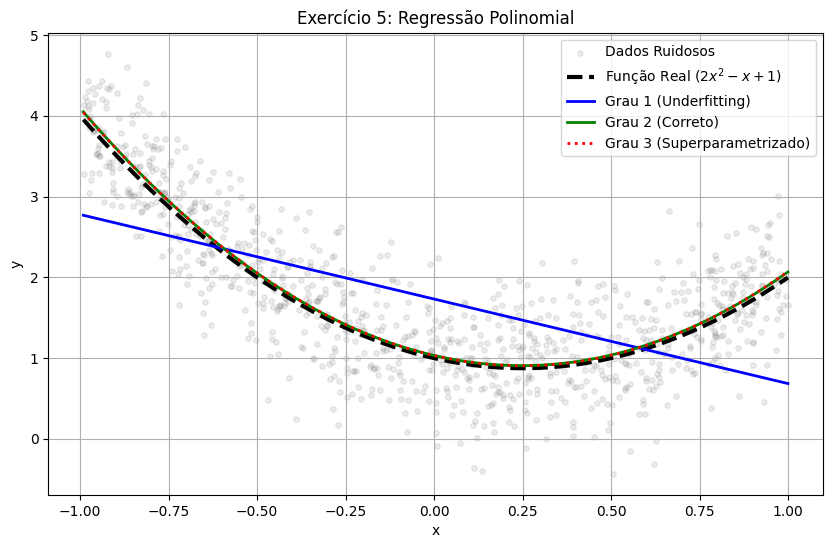

Grau 2 Estimado Intercepto 1.033 --- Coefs [-1.01350759  2.04865496]


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# 1. Dados
np.random.seed(42)
N = 1000
x = np.sort(np.random.uniform(-1, 1, N)).reshape(-1, 1) # Ordenado para o plot da linha não rabiscar
w = 0.5 * np.random.randn(N, 1) # sigma = 0.5
y = 2*(x**2) - x + 1
y_noisy = y + w

# 2. Grau 1 (Linear)
model_g1 = LinearRegression()
model_g1.fit(x, y_noisy)
y_pred_g1 = model_g1.predict(x)

# 3. Grau 2 (Quadrático - O modelo correto)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(x)
model_g2 = LinearRegression()
model_g2.fit(X_poly2, y_noisy)
y_pred_g2 = model_g2.predict(X_poly2)

# 4. Grau 3 (Cúbico - Overfitting / Superparametrizado)
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly3 = poly3.fit_transform(x)
model_g3 = LinearRegression()
model_g3.fit(X_poly3, y_noisy)
y_pred_g3 = model_g3.predict(X_poly3)

# 5. Visualização
plt.figure(figsize=(10, 6))
plt.scatter(x, y_noisy, alpha=0.15, color="gray", label="Dados Ruidosos", s=15)
plt.plot(x, y, color="black", linestyle="--", linewidth=3, label="Função Real ($2x^2 - x + 1$)")
plt.plot(x, y_pred_g1, color="blue", linewidth=2, label="Grau 1 (Underfitting)")
plt.plot(x, y_pred_g2, color="green", linewidth=2, label="Grau 2 (Correto)")
plt.plot(x, y_pred_g3, color="red", linewidth=2, linestyle=":", label="Grau 3 (Superparametrizado)")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Exercício 5: Regressão Polinomial")
plt.legend()
plt.grid(True)
plt.show()


print(f"Grau 2 Estimado Intercepto {model_g2.intercept_[0]:.3f} --- Coefs {model_g2.coef_[0]}")